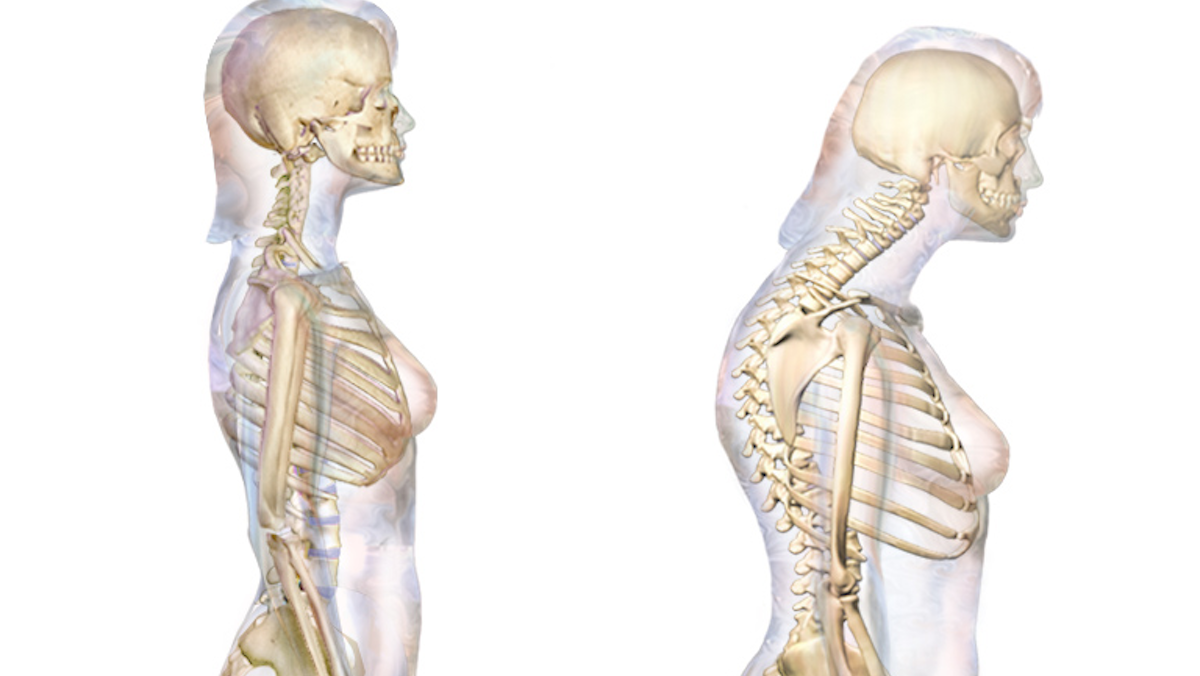

# PRACTICA #1: CIFOSIS

## **Descripción del proyecto**

En este proyecto, realizaremos un Análisis Exploratorio de Datos (EDA) básico sobre el conjunto de datos de la enfermedad cifosis.

La cifosis es una curvatura convexa anormalmente excesiva de la columna vertebral.

El conjunto de datos contiene 81 filas y 4 columnas que representan datos sobre niños que se han sometido a cirugía correctiva de la columna vertebral.

ENTRADAS: 1. Edad: en meses, 2. Número: el número de vértebras afectadas, 3. Inicio: el número de la primera vértebra (la más alta) operada.

SALIDAS: Cifosis que representa un factor con niveles ausentes presentes que indica si se presentó una cifosis (un tipo de deformación) después de la operación.

Utilizando el archivo "kyphosis.csv" incluido en el paquete del curso, escribe un script de python para realizar las siguientes tareas:


1.   Importar el archivo "cifosis.csv" utilizando Pandas
2.   Realizar un análisis exploratorio de datos (EDA) básico de los datos
3.   Enumerar la edad media, mínima y máxima (en años) considerada en este estudio utilizando 2 métodos
4.   Representar la matriz de correlaciones
5.   Convierte el tipo de datos de la columna edad de int64 a float64
6.   Definir una función que convierta la edad de meses a años
7. Aplicar la función a la columna "Edad" y añadir los resultados en una nueva columna titulada "Edad en años"
8. Cuáles son las características del niño mayor y del menor de este estudio?
9. Escala la columna "Edad" sin procesar (en meses) utilizando tanto la estandarización como la normalización.

## **1.- Inicialización del proyecto**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

In [ ]:
khyphosis = pd.read_csv('/content/drive/MyDrive/Datasets/P2_kyphosis - P2_kyphosis.csv')

## **2.- Análisis de Datos Exploratorio**

In [ ]:
print("Dataset Info")
khyphosis.info()

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Kyphosis  81 non-null     object
 1   Age       81 non-null     int64 
 2   Number    81 non-null     int64 
 3   Start     81 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 2.7+ KB


In [ ]:
khyphosis.describe()

,Age,Number,Start
count,81.000000,81.000000,81.000000
mean,83.654321,4.049383,11.493827
std,58.104251,1.619423,4.883962
min,1.000000,2.000000,1.000000
25%,26.000000,3.000000,9.000000
50%,87.000000,4.000000,13.000000
75%,130.000000,5.000000,16.000000
max,206.000000,10.000000,18.000000


## **3.- Enumerar edad media**

In [ ]:
(khyphosis['Age']/12).describe()

,Age
count,81.000000
mean,6.971193
std,4.842021
min,0.083333
25%,2.166667
50%,7.250000
75%,10.833333
max,17.166667


In [ ]:
(khyphosis['Age']/12).mean(), (khyphosis['Age']/12).min(), (khyphosis['Age']/12).max()

(np.float64(6.971193415637861), 0.08333333333333333, 17.166666666666668)

## **4.- Matriz de correlación**

<Axes: >

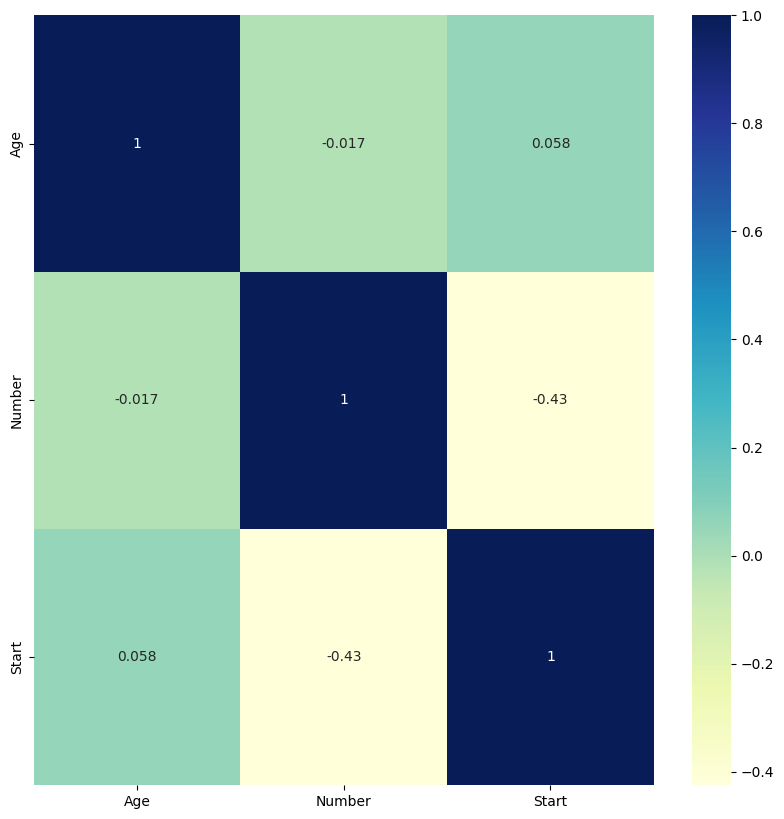

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

correlations = khyphosis.corr(numeric_only = True)
plt.figure(figsize=(10, 10))
sns.heatmap(correlations, annot=True, cmap="YlGnBu")

## **5.- Conversión de datos**

In [ ]:
khyphosis['Age'] = khyphosis['Age'].astype('float64')

display(khyphosis['Age'].dtype)

dtype('float64')

## **6.- Función para convertir datos de Edad de meses a años**

In [ ]:
def months_to_years(age_in_months):
    return age_in_months / 12

## **7.- Aplicar función y agregar característica**

In [ ]:
khyphosis['Edad en años'] = khyphosis['Age'].apply(months_to_years)

# Niño mayor


In [ ]:
oldest_child = khyphosis.loc[khyphosis['Edad en años'].idxmax()]
print("Características del niño mayor:")
display(oldest_child)

Características del niño mayor:


,73
Kyphosis,absent
Age,206.0
Number,4
Start,10
Edad en años,17.166667


# Niño Menor

In [ ]:
youngest_child = khyphosis.loc[khyphosis['Edad en años'].idxmin()]
print("Características del niño menor:")
display(youngest_child)

Características del niño menor:


,4
Kyphosis,absent
Age,1.0
Number,4
Start,15
Edad en años,0.083333


## **9.- Escalamiento de datos**

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Estandarización de la columna 'Age'
scaler_standard = StandardScaler()
khyphosis['Age_Standardized'] = scaler_standard.fit_transform(khyphosis[['Age']])

# Normalización de la columna 'Age'
scaler_minmax = MinMaxScaler()
khyphosis['Age_Normalized'] = scaler_minmax.fit_transform(khyphosis[['Age']])

print("DataFrame con columnas de Edad estandarizada y normalizada:")
display(khyphosis[['Age', 'Age_Standardized', 'Age_Normalized']].head())

DataFrame con columnas de Edad estandarizada y normalizada:


,Age,Age_Standardized,Age_Normalized
0,71.0,-0.219143,0.341463
1,158.0,1.287494,0.765854
2,128.0,0.767964,0.619512
3,2.0,-1.414063,0.004878
4,1.0,-1.431381,0.000000
